# 05 — Hourly vs Exact Time Latent ODE ablation

This notebook evaluates the effect of temporal resolution in the Latent ODE model on PhysioNet 2012 mortality prediction.  
Two representations are compared under the same architecture, optimization setup and evaluation protocol:
- hourly aggregation on a shared 0–48 h grid;
- patient-specific exact observation timestamps.
Model architecture, normalization, loss, optimizer and ODE solver are held fixed so that the comparison isolates the effect of temporal representation. Model selection is performed on a stratified validation split of Set A; B and C are used only for retrospective evaluation.

In [1]:
import sys, copy, random, time
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

cwd=Path.cwd().resolve()
if (cwd/'src').exists(): PROJECT_ROOT=cwd
elif (cwd.parent/'src').exists(): PROJECT_ROOT=cwd.parent
else: raise RuntimeError('Start Jupyter from repository root or notebooks/.')
sys.path.insert(0,str(PROJECT_ROOT))

from src.data.physionet import load_split, GENERAL_DESCRIPTORS
from src.data.preprocessing import build_vocab
from src.training.metrics import select_event1_threshold, challenge_metrics

RAW_DIR=PROJECT_ROOT/'data'/'raw'
SEED=42
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def reset_seeds(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
reset_seeds()
plt.rcParams['figure.dpi']=110
print('Project root:',PROJECT_ROOT)
print('Device:',DEVICE)

Project root: C:\Users\guido\git_projects\icu-continuous-forecasting
Device: cpu


## 1. Set-A development split

B/C are not loaded during development. Because Set C has already been inspected in earlier project iterations, B/C are now a **retrospective historical benchmark**; they are still protected by a strict code-level information firewall in this notebook.

In [2]:
A=load_split(RAW_DIR,split='set-a')
assert len(A)==4000 and all(r.label is not None for r in A)
yA=np.asarray([int(r.label) for r in A],dtype=np.int64)
idx=np.arange(len(A))
tr_idx,va_idx=train_test_split(idx,test_size=.20,random_state=SEED,stratify=yA)
A_tr=[A[i] for i in tr_idx]; A_va=[A[i] for i in va_idx]
dev_vocab=build_vocab(A_tr)
print('A train/val:',len(A_tr),len(A_va),'vocab:',len(dev_vocab))
print('Mortality:',round(np.mean([r.label for r in A_tr]),4),round(np.mean([r.label for r in A_va]),4))

A train/val: 3200 800 vocab: 36
Mortality: 0.1384 0.1388


## 2. Shared normalizer

To isolate timing, both arms use the same statistics estimated from **raw observed measurements** in A-development-train. Static-variable statistics are also fitted only there.

In [3]:
STATIC_NAMES=list(GENERAL_DESCRIPTORS)
@dataclass
class SharedNormalizer:
    value_mean: np.ndarray; value_std: np.ndarray
    static_mean: np.ndarray; static_std: np.ndarray

def fit_shared_normalizer(records,vocab):
    D=len(vocab); vi={v:j for j,v in enumerate(vocab)}
    sums=np.zeros(D,np.float64); sums2=np.zeros(D,np.float64); counts=np.zeros(D,np.int64)
    for rec in records:
        for var,pts in rec.values.items():
            j=vi.get(var)
            if j is None: continue
            for t,v in pts:
                t=float(t); v=float(v)
                if 0<=t<=48 and np.isfinite(v):
                    sums[j]+=v; sums2[j]+=v*v; counts[j]+=1
    if np.any(counts==0):
        raise RuntimeError('Variables without training observations: '+str([vocab[j] for j in np.flatnonzero(counts==0)]))
    mean=sums/counts; var=np.maximum(sums2/counts-mean**2,0); std=np.sqrt(var); std[std<1e-6]=1
    sr=np.asarray([[r.static.get(n,np.nan) for n in STATIC_NAMES] for r in records],dtype=np.float64)
    sm=np.nanmean(sr,0); ss=np.nanstd(sr,0); sm=np.nan_to_num(sm,nan=0.0); ss=np.where(np.isfinite(ss)&(ss>1e-6),ss,1.0)
    return SharedNormalizer(mean.astype('float32'),std.astype('float32'),sm.astype('float32'),ss.astype('float32'))

dev_norm=fit_shared_normalizer(A_tr,dev_vocab)
print('Shared raw-measurement normalizer fitted.')

Shared raw-measurement normalizer fitted.


## 3. Common batch interface and two temporal representations

Both datasets return the same tensors. Exact-time sequences are variable-length and padded only for batching; padded steps have zero mask and zero elapsed time.

In [4]:
@dataclass
class TemporalBatch:
    times: torch.Tensor; values: torch.Tensor; mask: torch.Tensor; delta_t: torch.Tensor
    static: torch.Tensor; labels: torch.Tensor; lengths: torch.Tensor; record_ids: list
    def to(self,device):
        return TemporalBatch(self.times.to(device),self.values.to(device),self.mask.to(device),self.delta_t.to(device),self.static.to(device),self.labels.to(device),self.lengths.to(device),self.record_ids)

def normalize_static(rec,norm):
    s=np.asarray([rec.static.get(n,np.nan) for n in STATIC_NAMES],dtype=np.float32)
    s=(s-norm.static_mean)/norm.static_std
    return np.nan_to_num(s,nan=0.,posinf=0.,neginf=0.).astype('float32')

def compute_delta(times,mask):
    T,D=mask.shape; out=np.zeros((T,D),np.float32); last=np.full(D,np.nan,np.float32)
    for k,t in enumerate(times):
        if k>0:
            seen=np.isfinite(last); out[k,seen]=float(t)-last[seen]; out[k,~seen]=float(t)
        obs=mask[k]>0; last[obs]=float(t)
    return out

def collate_items(items):
    lengths=np.asarray([len(x[0]) for x in items],np.int64); B=len(items); Tmax=int(lengths.max()); D=items[0][1].shape[1]
    times=np.zeros((B,Tmax),np.float32); values=np.full((B,Tmax,D),np.nan,np.float32); mask=np.zeros((B,Tmax,D),np.float32); delta=np.zeros((B,Tmax,D),np.float32)
    static=np.stack([x[4] for x in items]); labels=np.asarray([x[5] for x in items],np.float32); ids=[str(x[6]) for x in items]
    for i,(t,v,m,dt,*_) in enumerate(items):
        L=len(t); times[i,:L]=t; values[i,:L]=v; mask[i,:L]=m; delta[i,:L]=dt
        if L<Tmax: times[i,L:]=t[-1]
    return TemporalBatch(torch.from_numpy(times),torch.from_numpy(values),torch.from_numpy(mask),torch.from_numpy(delta),torch.from_numpy(static),torch.from_numpy(labels),torch.from_numpy(lengths),ids)

class HourlyDataset:
    def __init__(self,records,vocab,norm):
        self.records=list(records); self.vocab=list(vocab); self.vi={v:j for j,v in enumerate(vocab)}; self.norm=norm; self.times=np.arange(49,dtype=np.float32)
    def __len__(self): return len(self.records)
    def _one(self,i):
        rec=self.records[i]; D=len(self.vocab); sums=np.zeros((49,D),np.float32); counts=np.zeros((49,D),np.float32)
        for var,pts in rec.values.items():
            j=self.vi.get(var)
            if j is None: continue
            for t,v in pts:
                t=float(t); v=float(v)
                if 0<=t<=48 and np.isfinite(v):
                    b=min(int(round(t)),48); sums[b,j]+=v; counts[b,j]+=1
        mask=(counts>0).astype(np.float32); raw=np.zeros_like(sums); obs=counts>0; raw[obs]=sums[obs]/counts[obs]
        z=np.zeros_like(raw); M=np.broadcast_to(self.norm.value_mean,raw.shape); S=np.broadcast_to(self.norm.value_std,raw.shape); z[obs]=(raw[obs]-M[obs])/S[obs]
        vals=np.where(mask>0,z,np.nan).astype(np.float32); dt=compute_delta(self.times,mask); st=normalize_static(rec,self.norm); lab=np.nan if rec.label is None else float(rec.label)
        return self.times.copy(),vals,mask,dt,st,lab,rec.record_id
    def collate(self,idx): return collate_items([self._one(i) for i in idx])

def _minute_key(t):
    return int(round(float(t)*60.0))

def patient_event_times(rec):
    keys={0}
    for var,pts in rec.values.items():
        if not var or not var.strip(): continue
        for t,_ in pts:
            t=float(t)
            if 0<=t<=48: keys.add(_minute_key(t))
    return np.asarray([k/60.0 for k in sorted(keys)],dtype=np.float32)

class ExactTimeDataset:
    def __init__(self,records,vocab,norm):
        self.records=list(records); self.vocab=list(vocab); self.vi={v:j for j,v in enumerate(vocab)}; self.norm=norm
    def __len__(self): return len(self.records)
    def _one(self,i):
        rec=self.records[i]; times=patient_event_times(rec); ti={_minute_key(t):k for k,t in enumerate(times.tolist())}; T=len(times); D=len(self.vocab)
        sums=np.zeros((T,D),np.float32); counts=np.zeros((T,D),np.float32)
        for var,pts in rec.values.items():
            j=self.vi.get(var)
            if j is None: continue
            for t,v in pts:
                t=float(t); v=float(v)
                if 0<=t<=48 and np.isfinite(v):
                    k=ti[_minute_key(t)]; sums[k,j]+=v; counts[k,j]+=1
        mask=(counts>0).astype(np.float32); raw=np.zeros_like(sums); obs=counts>0; raw[obs]=sums[obs]/counts[obs]
        z=np.zeros_like(raw); M=np.broadcast_to(self.norm.value_mean,raw.shape); S=np.broadcast_to(self.norm.value_std,raw.shape); z[obs]=(raw[obs]-M[obs])/S[obs]
        vals=np.where(mask>0,z,np.nan).astype(np.float32); dt=compute_delta(times,mask); st=normalize_static(rec,self.norm); lab=np.nan if rec.label is None else float(rec.label)
        return times,vals,mask,dt,st,lab,rec.record_id
    def collate(self,idx): return collate_items([self._one(i) for i in idx])

In [5]:
hourly_tr=HourlyDataset(A_tr,dev_vocab,dev_norm); hourly_va=HourlyDataset(A_va,dev_vocab,dev_norm)
exact_tr=ExactTimeDataset(A_tr,dev_vocab,dev_norm); exact_va=ExactTimeDataset(A_va,dev_vocab,dev_norm)
h=hourly_tr.collate(list(range(16))); e=exact_tr.collate(list(range(16)))
assert np.all(h.lengths.numpy()==49); assert len(np.unique(e.lengths.numpy()))>1
all_times=np.concatenate([patient_event_times(r) for r in A])
frac=np.mean(np.abs(all_times-np.round(all_times))>1e-8)
print('Hourly probe lengths:',int(h.lengths.min()),int(h.lengths.max()))
print('Exact probe lengths:',int(e.lengths.min()),int(e.lengths.max()))
print('Fraction exact timestamps off integer hours:',round(float(frac),4))
assert frac>0

Hourly probe lengths: 49 49
Exact probe lengths: 48 157
Fraction exact timestamps off integer hours: 0.971


## 4. Shared Latent ODE architecture

This mirrors `src/models/latent_ode.py`: backward GRUCell encoder, `tanh(delta/24)`, identical ODE MLP, decoder, and mortality classifier from the posterior **mean** plus static covariates. Both arms use the same batched RK4 integrator so solver choice is not a confound.

In [6]:
class ODEFunc(nn.Module):
    def __init__(self,Z,H=64):
        super().__init__(); self.net=nn.Sequential(nn.Linear(Z,H),nn.Tanh(),nn.Linear(H,H),nn.Tanh(),nn.Linear(H,Z))
    def forward(self,z): return self.net(z)

class Encoder(nn.Module):
    def __init__(self,D,Z,H=64):
        super().__init__(); self.cell=nn.GRUCell(3*D,H); self.H=H; self.to_stats=nn.Linear(H,2*Z)
    def forward(self,filled,mask,dt,lengths):
        B,T,D=filled.shape; h=torch.zeros(B,self.H,device=filled.device)
        for k in reversed(range(T)):
            active=lengths>k
            x=torch.cat([filled[:,k],mask[:,k],torch.tanh(dt[:,k]/24.0)],-1)
            h_new=self.cell(x,h); h=torch.where(active.unsqueeze(-1),h_new,h)
        return self.to_stats(h).chunk(2,-1)

class ControlledLatentODE(nn.Module):
    def __init__(self,D,S,Z=16,H=64,max_step=1.0):
        super().__init__(); self.enc=Encoder(D,Z,H); self.f=ODEFunc(Z,H); self.dec=nn.Sequential(nn.Linear(Z,H),nn.ReLU(),nn.Linear(H,D)); self.clf=nn.Sequential(nn.Linear(Z+S,H),nn.ReLU(),nn.Linear(H,1)); self.max_step=float(max_step)
    @staticmethod
    def fill(values,mask):
        B,T,D=values.shape; out=torch.zeros_like(values); last=torch.zeros(B,D,device=values.device); seen=torch.zeros(B,D,dtype=torch.bool,device=values.device)
        for k in range(T):
            obs=mask[:,k]>0; cur=torch.nan_to_num(values[:,k],nan=0.0); last=torch.where(obs,cur,last); seen=seen|obs; out[:,k]=torch.where(seen,last,torch.zeros_like(last))
        return out
    def rk4(self,z,dt):
        k1=self.f(z); k2=self.f(z+.5*dt*k1); k3=self.f(z+.5*dt*k2); k4=self.f(z+dt*k3); return z+(dt/6.0)*(k1+2*k2+2*k3+k4)
    def advance(self,z,dt):
        mx=float(dt.max().detach().cpu())
        if mx<=0: return z
        n=max(1,int(np.ceil(mx/self.max_step))); h=dt/n
        for _ in range(n): z=self.rk4(z,h)
        return z
    def forward(self,b,sample=True):
        filled=self.fill(b.values,b.mask); mean,logvar=self.enc(filled,b.mask,b.delta_t,b.lengths)
        z=mean+torch.randn_like(mean)*torch.exp(.5*logvar) if sample else mean
        recons=[self.dec(z)]; T=b.values.shape[1]
        for k in range(1,T):
            active=b.lengths>k; dt=(b.times[:,k]-b.times[:,k-1]).clamp_min(0); dt=torch.where(active,dt,torch.zeros_like(dt)).unsqueeze(-1)
            znew=self.advance(z,dt); z=torch.where(active.unsqueeze(-1),znew,z); recons.append(self.dec(z))
        recon=torch.stack(recons,1)
        logits=self.clf(torch.cat([mean,torch.nan_to_num(b.static,nan=0.0)],-1)).squeeze(-1)
        return logits,recon,mean,logvar

def kl_standard_normal(mean,logvar): return -.5*torch.sum(1+logvar-mean.pow(2)-logvar.exp(),-1)
def masked_mse(recon,values,mask):
    target=torch.nan_to_num(values,nan=0.0); sq=(recon-target).pow(2)*mask; return sq.sum((-1,-2))/mask.sum((-1,-2)).clamp_min(1)

## 5. Training protocol and checkpoints

AUPRC selects the best epoch; Event-1 threshold is selected on A-validation only. Checkpoint names are new, so this run cannot accidentally resume the old flawed Notebook 05.

In [7]:
BATCH=64; MAX_EPOCHS=30; PATIENCE=6; LR=1e-3; GRAD_CLIP=5.; RECON_W=.1; KL_W=1e-3; MAX_RK4_STEP=1.0
CKPT_DIR=PROJECT_ROOT/'checkpoints'; CKPT_DIR.mkdir(exist_ok=True); FORCE_RESTART=False; FORMAT='nb05_controlled_v1'

def paths(tag): return CKPT_DIR/f'nb05_{tag}_latest.pt',CKPT_DIR/f'nb05_{tag}_best.pt',CKPT_DIR/f'nb05_{tag}_final.pt'
def batches(ds,shuffle=False,epoch=0):
    ids=np.arange(len(ds))
    if shuffle: np.random.RandomState(SEED+int(epoch)).shuffle(ids)
    for s in range(0,len(ids),BATCH): yield ds.collate(ids[s:s+BATCH].tolist()).to(DEVICE)
def labels(ds): return np.asarray([np.nan if r.label is None else float(r.label) for r in ds.records],np.float32)

def train_epoch(model,ds,opt,epoch):
    model.train(); bce=nn.BCEWithLogitsLoss(); total=n=0
    for b in batches(ds,True,epoch):
        opt.zero_grad(set_to_none=True); logits,recon,mean,logvar=model(b,True); loss=bce(logits,b.labels.float())+RECON_W*masked_mse(recon,b.values,b.mask).mean()+KL_W*kl_standard_normal(mean,logvar).mean(); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); opt.step(); bs=len(b.labels); total+=float(loss.detach())*bs; n+=bs
    return total/n
@torch.no_grad()
def predict(model,ds):
    model.eval(); out=[]
    for b in batches(ds): out.append(torch.sigmoid(model(b,False)[0]).cpu().numpy())
    return np.concatenate(out)

def develop(model,tr,va,tag):
    latest,best,_=paths(tag)
    if FORCE_RESTART:
        for p in (latest,best):
            if p.exists(): p.unlink()
    model=model.to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=LR); best_ap=-np.inf; best_ep=None; stale=0; hist=[]; start=1
    if latest.exists():
        c=torch.load(latest,map_location=DEVICE,weights_only=False); assert c['format']==FORMAT; model.load_state_dict(c['model']); opt.load_state_dict(c['opt']); best_ap=c['best_ap']; best_ep=c['best_ep']; stale=c['stale']; hist=c['hist']; start=c['epoch']+1; torch.set_rng_state(c['torch_rng']); np.random.set_state(c['numpy_rng']); random.setstate(c['python_rng']); print(tag,'resume from',start)
    y=labels(va)
    for ep in range(start,MAX_EPOCHS+1):
        t0=time.perf_counter(); loss=train_epoch(model,tr,opt,ep); r=predict(model,va); auc=roc_auc_score(y,r); ap=average_precision_score(y,r); sec=time.perf_counter()-t0; imp=ap>best_ap+1e-5
        if imp: best_ap=ap; best_ep=ep; stale=0; torch.save({'format':FORMAT,'model':copy.deepcopy(model.state_dict()),'epoch':ep,'ap':ap},best)
        else: stale+=1
        hist.append({'epoch':ep,'loss':loss,'val_AUROC':auc,'val_AUPRC':ap,'seconds':sec})
        torch.save({'format':FORMAT,'model':model.state_dict(),'opt':opt.state_dict(),'epoch':ep,'best_ap':best_ap,'best_ep':best_ep,'stale':stale,'hist':hist,'torch_rng':torch.get_rng_state(),'numpy_rng':np.random.get_state(),'python_rng':random.getstate()},latest)
        print(f'[{tag}] {ep:02d} loss={loss:.4f} val_AUROC={auc:.4f} val_AUPRC={ap:.4f} time={sec:.1f}s '+('[BEST]' if imp else f'[patience {stale}/{PATIENCE}]'))
        if stale>=PATIENCE: break
    c=torch.load(best,map_location=DEVICE,weights_only=False); model.load_state_dict(c['model']); return model,int(c['epoch']),pd.DataFrame(hist)

def train_fixed(model,ds,epochs,tag):
    _,_,fp=paths(tag)
    if FORCE_RESTART and fp.exists(): fp.unlink()
    model=model.to(DEVICE); opt=torch.optim.Adam(model.parameters(),lr=LR); start=1
    if fp.exists():
        c=torch.load(fp,map_location=DEVICE,weights_only=False); assert c['format']==FORMAT and c['target']==int(epochs); model.load_state_dict(c['model']); opt.load_state_dict(c['opt']); start=c['epoch']+1; print(tag,'final resume from',start)
    for ep in range(start,epochs+1):
        t0=time.perf_counter(); loss=train_epoch(model,ds,opt,ep); sec=time.perf_counter()-t0; torch.save({'format':FORMAT,'model':model.state_dict(),'opt':opt.state_dict(),'epoch':ep,'target':int(epochs)},fp); print(f'[{tag}] {ep:02d}/{epochs:02d} loss={loss:.4f} time={sec:.1f}s')
    return model

In [8]:
D=len(dev_vocab); S=len(STATIC_NAMES)
def make_model(D=D): return ControlledLatentODE(D,S,Z=16,H=64,max_step=MAX_RK4_STEP)
for tag,ds in [('hourly',hourly_tr),('exact',exact_tr)]:
    reset_seeds(); m=make_model().to(DEVICE); b=ds.collate(list(range(8))).to(DEVICE)
    with torch.no_grad(): logits,recon,mean,logvar=m(b,False)
    assert logits.shape==(8,) and recon.shape==b.values.shape and torch.isfinite(logits).all()
    print(tag,'smoke OK',tuple(b.values.shape))

hourly smoke OK (8, 49, 36)
exact smoke OK (8, 112, 36)


## 6. Set-A development: hourly then exact-time

[controlled_hourly] 01 loss=0.5773 val_AUROC=0.7901 val_AUPRC=0.3465 time=19.6s [BEST]
[controlled_hourly] 02 loss=0.4491 val_AUROC=0.8165 val_AUPRC=0.3742 time=20.4s [BEST]
[controlled_hourly] 03 loss=0.4283 val_AUROC=0.8265 val_AUPRC=0.4094 time=23.6s [BEST]
[controlled_hourly] 04 loss=0.4120 val_AUROC=0.8365 val_AUPRC=0.4541 time=30.5s [BEST]
[controlled_hourly] 05 loss=0.3992 val_AUROC=0.8522 val_AUPRC=0.4758 time=21.6s [BEST]
[controlled_hourly] 06 loss=0.3857 val_AUROC=0.8682 val_AUPRC=0.5220 time=20.8s [BEST]
[controlled_hourly] 07 loss=0.3702 val_AUROC=0.8603 val_AUPRC=0.5069 time=21.4s [patience 1/6]
[controlled_hourly] 08 loss=0.3628 val_AUROC=0.8605 val_AUPRC=0.5105 time=19.7s [patience 2/6]
[controlled_hourly] 09 loss=0.3485 val_AUROC=0.8462 val_AUPRC=0.4678 time=19.1s [patience 3/6]
[controlled_hourly] 10 loss=0.3287 val_AUROC=0.8559 val_AUPRC=0.5059 time=19.9s [patience 4/6]
[controlled_hourly] 11 loss=0.3146 val_AUROC=0.8507 val_AUPRC=0.4859 time=19.4s [patience 5/6]
[co

,epochs,threshold,val_AUROC,val_AUPRC
Representation,,,,
Hourly controlled,6,0.2640,0.8682,0.5220
Exact-time controlled,6,0.3022,0.8193,0.4248


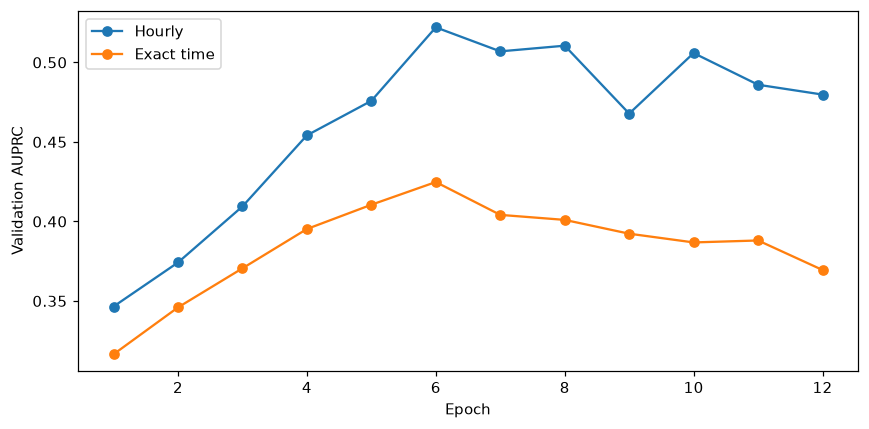

In [9]:
reset_seeds(); hourly_dev,hourly_ep,hourly_hist=develop(make_model(),hourly_tr,hourly_va,'controlled_hourly'); hourly_val=predict(hourly_dev,hourly_va); hourly_thr=select_event1_threshold(labels(hourly_va),hourly_val)
reset_seeds(); exact_dev,exact_ep,exact_hist=develop(make_model(),exact_tr,exact_va,'controlled_exact'); exact_val=predict(exact_dev,exact_va); exact_thr=select_event1_threshold(labels(exact_va),exact_val)
sel=pd.DataFrame([
 {'Representation':'Hourly controlled','epochs':hourly_ep,'threshold':hourly_thr,'val_AUROC':roc_auc_score(labels(hourly_va),hourly_val),'val_AUPRC':average_precision_score(labels(hourly_va),hourly_val)},
 {'Representation':'Exact-time controlled','epochs':exact_ep,'threshold':exact_thr,'val_AUROC':roc_auc_score(labels(exact_va),exact_val),'val_AUPRC':average_precision_score(labels(exact_va),exact_val)}])
display(sel.set_index('Representation').round(4))
plt.figure(figsize=(8,4)); plt.plot(hourly_hist.epoch,hourly_hist.val_AUPRC,marker='o',label='Hourly'); plt.plot(exact_hist.epoch,exact_hist.val_AUPRC,marker='o',label='Exact time'); plt.xlabel('Epoch'); plt.ylabel('Validation AUPRC'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Freeze choices, refit on all A, and train final models

In [10]:
final_vocab=build_vocab(A); assert final_vocab==dev_vocab
final_norm=fit_shared_normalizer(A,final_vocab)
A_hourly=HourlyDataset(A,final_vocab,final_norm); A_exact=ExactTimeDataset(A,final_vocab,final_norm)
D=len(final_vocab)
def make_final(): return ControlledLatentODE(D,len(STATIC_NAMES),Z=16,H=64,max_step=MAX_RK4_STEP)
reset_seeds(); hourly_final=train_fixed(make_final(),A_hourly,hourly_ep,'controlled_hourly')
reset_seeds(); exact_final=train_fixed(make_final(),A_exact,exact_ep,'controlled_exact')

[controlled_hourly] 01/06 loss=0.5585 time=22.4s
[controlled_hourly] 02/06 loss=0.4399 time=22.5s
[controlled_hourly] 03/06 loss=0.4151 time=22.3s
[controlled_hourly] 04/06 loss=0.4033 time=22.7s
[controlled_hourly] 05/06 loss=0.3876 time=25.1s
[controlled_hourly] 06/06 loss=0.3713 time=21.8s
[controlled_exact] 01/06 loss=0.5689 time=71.9s
[controlled_exact] 02/06 loss=0.4558 time=73.7s
[controlled_exact] 03/06 loss=0.4368 time=77.0s
[controlled_exact] 04/06 loss=0.4313 time=89.3s
[controlled_exact] 05/06 loss=0.4201 time=70.6s
[controlled_exact] 06/06 loss=0.4052 time=67.8s


## 8. Load B/C only after everything is frozen; freeze predictions before outcomes

In [11]:
B=load_split(RAW_DIR,split='set-b'); C=load_split(RAW_DIR,split='set-c')
assert len(B)==len(C)==4000 and all(r.label is None for r in B) and all(r.label is None for r in C)
assert not (set(build_vocab(B))-set(final_vocab)); assert not (set(build_vocab(C))-set(final_vocab))
B_h=HourlyDataset(B,final_vocab,final_norm); C_h=HourlyDataset(C,final_vocab,final_norm); B_e=ExactTimeDataset(B,final_vocab,final_norm); C_e=ExactTimeDataset(C,final_vocab,final_norm)
risk_B_h=predict(hourly_final,B_h); risk_C_h=predict(hourly_final,C_h); risk_B_e=predict(exact_final,B_e); risk_C_e=predict(exact_final,C_e)
for r in (risk_B_h,risk_C_h,risk_B_e,risk_C_e): assert len(r)==4000 and np.isfinite(r).all() and np.all((r>=0)&(r<=1))
print('PREDICTIONS FROZEN. B/C outcomes have not been read up to this point.')

PREDICTIONS FROZEN. B/C outcomes have not been read up to this point.


## 9. Retrospective scoring and primary controlled ablation

These are retrospective historical results. Do not revise the model after inspecting them.

In [12]:
def read_outcomes(path):
    df=pd.read_csv(path,dtype={'RecordID':str}); df['RecordID']=df['RecordID'].str.strip(); assert df.RecordID.is_unique; return df.set_index('RecordID')['In-hospital_death']
def aligned_y(records,mp):
    ids=[str(r.record_id).strip() for r in records]; assert not(set(ids)-set(mp.index)); assert not(set(mp.index)-set(ids)); return np.asarray([int(mp.loc[x]) for x in ids],np.int64)
yB=aligned_y(B,read_outcomes(RAW_DIR/'Outcomes-b.txt')); yC=aligned_y(C,read_outcomes(RAW_DIR/'Outcomes-c.txt'))
rows=[]
for rep,rb,rc,thr in [('Hourly controlled',risk_B_h,risk_C_h,hourly_thr),('Exact-time controlled',risk_B_e,risk_C_e,exact_thr)]:
    rows.append({'Representation':rep,'Set':'B',**challenge_metrics(yB,rb,thr)}); rows.append({'Representation':rep,'Set':'C',**challenge_metrics(yC,rc,thr)})
res=pd.DataFrame(rows).rename(columns={'auroc':'AUROC','auprc':'AUPRC','event1':'Event1','sensitivity':'Sensitivity','ppv':'PPV','threshold':'Threshold','event2':'Event2'})
display(res.round(4))
c=res[res.Set=='C']; h=c[c.Representation=='Hourly controlled'].iloc[0]; e=c[c.Representation=='Exact-time controlled'].iloc[0]
delta=pd.DataFrame([{'Comparison':'Exact-time minus hourly','Δ AUROC':e.AUROC-h.AUROC,'Δ AUPRC':e.AUPRC-h.AUPRC,'Δ Event1':e.Event1-h.Event1,'Δ Event2':e.Event2-h.Event2}]).set_index('Comparison')
display(delta.round(4))

,Representation,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,Hourly controlled,B,0.8480,0.4803,0.3853,0.6919,0.3853,0.2640,102.1637
1,Hourly controlled,C,0.8474,0.4974,0.4000,0.6769,0.4000,0.2640,80.1770
2,Exact-time controlled,B,0.7862,0.3829,0.3431,0.5370,0.3431,0.3022,103.6744
3,Exact-time controlled,C,0.7863,0.3834,0.3624,0.5402,0.3624,0.3022,82.8173


,Δ AUROC,Δ AUPRC,Δ Event1,Δ Event2
Comparison,,,,
Exact-time minus hourly,-0.0611,-0.114,-0.0376,2.6403


## 10. Conclusions

Under a controlled architecture and optimization setup, preserving exact patient-specific timestamps does not improve mortality prediction over the hourly representation. The hourly model achieves substantially better discrimination on Set C (AUROC 0.8474, AUPRC 0.4974) than the exact-time variant (AUROC 0.7863, AUPRC 0.3834).
The same gap is already visible on Set-A validation, suggesting that the difference is not specific to the retrospective test sets. Event 2 remains of comparable magnitude across the two representations, while the main degradation is in ranking performance.
For this Latent ODE configuration, increasing temporal resolution therefore adds sequence complexity without producing a corresponding gain in predictive information. Hourly aggregation appears to provide a more effective bias–variance trade-off for the mortality classification task.